# Install and imports

In [1]:
# Cell 1 - minimal installs & imports
# (timm might already be installed on Kaggle; this installs only if missing)
import pkgutil, sys, subprocess
def pip_install(pkg):
    name = pkg.split("==")[0]
    if not pkgutil.find_loader(name):
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

pip_install("timm==0.9.2")

# Standard imports
import os, time, random, json
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import timm
import torchvision
from torchvision import transforms, datasets

print("torch", torch.__version__, "timm", timm.__version__)


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

torch 2.6.0+cu124 timm 1.0.19


# seed & device

In [2]:
# Cell 2 - seed and device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


# Paths, hyperparameters, and quick settings

In [3]:
# Cell 3 - paths & hyperparameters
DATA_ROOT = Path("/kaggle/input/poultry-diseases/data/data")  # dataset root: train/val/test
OUTPUT_DIR = Path("/kaggle/working/poultry_model")
CKPT_DIR = OUTPUT_DIR / "checkpoints"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 64           # try 64 or 48; reduce to 32/16 on OOM
NUM_WORKERS = 6           # adjust to your environment (6-12 on Kaggle)
NUM_EPOCHS = 30
BASE_LR = 2e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 6              # early stopping on val F1
MAX_LR_FACTOR = 8.0       # OneCycle peak multiplier (peak = BASE_LR * MAX_LR_FACTOR)

print("Data root:", DATA_ROOT.exists(), "  Output:", OUTPUT_DIR)


Data root: True   Output: /kaggle/working/poultry_model


# Class mapping & helper to collect images

In [4]:
# Cell 4 - metrics & report helpers (pure numpy, sklearn-free)
import numpy as np

UNIFIED_CLASSES = None  # will be filled after dataset creation

def confusion_matrix_numpy(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

def precision_recall_f1_from_cm(cm):
    tp = cm.diagonal().astype(np.float64)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    with np.errstate(divide='ignore', invalid='ignore'):
        precision = np.where(tp + fp == 0, 0.0, tp / (tp + fp))
        recall = np.where(tp + fn == 0, 0.0, tp / (tp + fn))
        f1 = np.where(precision + recall == 0, 0.0, 2 * precision * recall / (precision + recall))
    support = cm.sum(axis=1).astype(np.int64)
    return precision, recall, f1, support

def compute_metrics(y_true, y_pred, class_names=None):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    num_classes = int(max(y_true.max() if len(y_true)>0 else 0, y_pred.max() if len(y_pred)>0 else 0) + 1)
    cm = confusion_matrix_numpy(y_true, y_pred, num_classes)
    precision, recall, f1, support = precision_recall_f1_from_cm(cm)
    accuracy = float((y_true == y_pred).sum() / len(y_true)) if len(y_true) > 0 else 0.0
    return {
        "accuracy": accuracy,
        "f1_macro": float(np.nanmean(f1)),
        "precision_macro": float(np.nanmean(precision)),
        "recall_macro": float(np.nanmean(recall)),
        "confusion_matrix": cm,
        "per_class": {"precision": precision, "recall": recall, "f1": f1, "support": support}
    }

def classification_report_str(y_true, y_pred, target_names=None, digits=4):
    # Builds a human readable classification report string
    if target_names is None:
        target_names = [str(i) for i in range(max(len(y_true), len(y_pred)))]
    res = compute_metrics(y_true, y_pred)
    cm = res["confusion_matrix"]
    precision = res["per_class"]["precision"]
    recall = res["per_class"]["recall"]
    f1 = res["per_class"]["f1"]
    support = res["per_class"]["support"]
    lines = []
    lines.append(" " * 20 + "precision    recall  f1-score   support")
    for i, name in enumerate(target_names):
        lines.append(f"{name:20s} {precision[i]:9.{digits}f} {recall[i]:9.{digits}f} {f1[i]:9.{digits}f} {support[i]:9d}")
    total = support.sum()
    acc = res["accuracy"]
    lines.append("")
    lines.append(f"accuracy                           {acc:0.{digits}f} {int(total):9d}")
    lines.append(f"macro avg     {res['precision_macro']:9.{digits}f} {res['recall_macro']:9.{digits}f} {res['f1_macro']:9.{digits}f} {int(total):9d}")
    with np.errstate(divide='ignore', invalid='ignore'):
        weights = support / support.sum() if support.sum() > 0 else np.zeros_like(support, dtype=float)
    weighted_prec = float(np.sum(precision * weights))
    weighted_rec = float(np.sum(recall * weights))
    weighted_f1 = float(np.sum(f1 * weights))
    lines.append(f"weighted avg  {weighted_prec:9.{digits}f} {weighted_rec:9.{digits}f} {weighted_f1:9.{digits}f} {int(total):9d}")
    return "\n".join(lines)


# Transforms, Datasets, and DataLoaders (fast settings)

In [5]:
# Cell 5 - transforms and dataloaders (uses torchvision transforms & ImageFolder)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
])

train_dir = DATA_ROOT / "train"
val_dir   = DATA_ROOT / "val"
test_dir  = DATA_ROOT / "test"

train_dataset = datasets.ImageFolder(root=str(train_dir), transform=train_transform)
val_dataset   = datasets.ImageFolder(root=str(val_dir), transform=val_transform)
test_dataset  = datasets.ImageFolder(root=str(test_dir), transform=val_transform)

# fill class names for metrics usage
UNIFIED_CLASSES = train_dataset.classes
print("Classes:", UNIFIED_CLASSES)

# DataLoader fast settings
def make_dataloader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS):
    try:
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers,
                          pin_memory=True, persistent_workers=True, prefetch_factor=2)
    except TypeError:
        # older PyTorch kernels don't support persistent_workers or prefetch_factor
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers, pin_memory=True)

train_loader = make_dataloader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = make_dataloader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = make_dataloader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Batches - train:", len(train_loader), "val:", len(val_loader), "test:", len(test_loader))


Classes: ['Coccidiosis', 'Healthy', 'New Castle Disease', 'Salmonella']
Batches - train: 6250 val: 625 test: 1105


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# Model creation (EfficientNet-B0), loss, optimizer, scheduler

In [6]:
# Cell 6 - create model, criterion, optimizer, scheduler factory
def create_model(num_classes=len(UNIFIED_CLASSES), pretrained=True):
    model = timm.create_model("efficientnet_b0", pretrained=pretrained, num_classes=num_classes)
    return model

model = create_model(len(UNIFIED_CLASSES), pretrained=True).to(device)
# optimizer & scheduler will be created inside train function (OneCycleLR)
criterion = nn.CrossEntropyLoss()
print("Model created. #params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model created. #params: 4012672


# Training loop with AMP, OneCycleLR, checkpointing, early stopping

In [7]:
# Cell 7 - training function (saves best by val_f1)
import math, time
from pathlib import Path

def train_model(model, train_loader, val_loader, tag="effnet", epochs=NUM_EPOCHS, base_lr=BASE_LR,
                weight_decay=WEIGHT_DECAY, max_lr_factor=MAX_LR_FACTOR, patience=PATIENCE, batch_size=BATCH_SIZE):

    device = next(model.parameters()).device
    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
    steps_per_epoch = max(1, len(train_loader))
    total_steps = epochs * steps_per_epoch
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=base_lr * max_lr_factor,
                                                    total_steps=total_steps, pct_start=0.1, anneal_strategy="cos", final_div_factor=100)
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

    best_f1 = -1.0
    best_ckpt_path = None
    training_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
    patience_counter = 0

    for epoch in range(1, epochs+1):
        t0 = time.time()
        # ---- train
        model.train()
        running_loss = 0.0
        total = 0
        correct = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad()
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    logits = model(xb)
                    loss = criterion(logits, yb)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

            # OneCycleLR step per batch
            try:
                scheduler.step()
            except Exception:
                pass

            running_loss += float(loss.item()) * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            total += yb.size(0)
            correct += (preds == yb).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- validation
        model.eval()
        val_running_loss = 0.0
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                if scaler is not None:
                    with torch.cuda.amp.autocast():
                        logits = model(xb)
                        loss = criterion(logits, yb)
                else:
                    logits = model(xb)
                    loss = criterion(logits, yb)
                val_running_loss += float(loss.item()) * xb.size(0)
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                val_preds.extend(preds.tolist())
                val_targets.extend(yb.cpu().numpy().tolist())

        val_loss = val_running_loss / len(val_loader.dataset)
        metrics = compute_metrics(val_targets, val_preds)
        val_acc = metrics["accuracy"]
        val_f1 = metrics["f1_macro"]

        # Logging & history
        training_history["train_loss"].append(train_loss)
        training_history["val_loss"].append(val_loss)
        training_history["train_acc"].append(train_acc)
        training_history["val_acc"].append(val_acc)
        training_history["val_f1"].append(val_f1)

        epoch_time = time.time() - t0
        print(f"Epoch {epoch}/{epochs} - train_loss={train_loss:.4f} val_loss={val_loss:.4f} train_acc={train_acc*100:.2f}% val_acc={val_acc*100:.2f}% val_f1={val_f1:.4f} time={epoch_time:.1f}s")

        # checkpoint last
        last_ckpt = CKPT_DIR / f"{tag}_last.pth"
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_f1": best_f1
        }, last_ckpt)

        # save best by val_f1
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_ckpt_path = CKPT_DIR / f"{tag}_best.pth"
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_f1": best_f1
            }, best_ckpt_path)
            print("Saved new BEST:", best_ckpt_path)
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"Patience {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    return best_ckpt_path, training_history


# Run training (train once)

In [8]:
# Cell 8 - run training (this will take several hours depending on GPU)
best_ckpt, history = train_model(model, train_loader, val_loader, tag="efficientnet_b0_ds2", epochs=NUM_EPOCHS,
                                base_lr=BASE_LR, weight_decay=WEIGHT_DECAY, max_lr_factor=MAX_LR_FACTOR, patience=PATIENCE)

print("Best checkpoint:", best_ckpt)
# Save history
with open(OUTPUT_DIR/"history.json","w") as f:
    json.dump(history, f)


/tmp/ipykernel_47/3435023961.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/tmp/ipykernel_47/3435023961.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/tmp/ipykernel_47/3435023961.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` 

Epoch 1/30 - train_loss=0.2838 val_loss=0.1825 train_acc=90.29% val_acc=93.39% val_f1=0.9341 time=1252.9s
Saved new BEST: /kaggle/working/poultry_model/checkpoints/efficientnet_b0_ds2_best.pth
Epoch 2/30 - train_loss=0.1706 val_loss=0.1824 train_acc=93.70% val_acc=93.60% val_f1=0.9356 time=1080.6s
Saved new BEST: /kaggle/working/poultry_model/checkpoints/efficientnet_b0_ds2_best.pth
Epoch 3/30 - train_loss=0.1727 val_loss=0.1638 train_acc=93.63% val_acc=94.23% val_f1=0.9422 time=1081.9s
Saved new BEST: /kaggle/working/poultry_model/checkpoints/efficientnet_b0_ds2_best.pth
Epoch 4/30 - train_loss=0.1420 val_loss=0.1197 train_acc=94.76% val_acc=95.62% val_f1=0.9563 time=1080.0s
Saved new BEST: /kaggle/working/poultry_model/checkpoints/efficientnet_b0_ds2_best.pth
Epoch 5/30 - train_loss=0.1188 val_loss=0.1280 train_acc=95.56% val_acc=95.28% val_f1=0.9529 time=1082.4s
Patience 1/6
Epoch 6/30 - train_loss=0.1042 val_loss=0.1021 train_acc=96.14% val_acc=96.12% val_f1=0.9612 time=1078.0s
Sav

# Load best model & evaluate on test set (compute metrics & confusion matrix)

In [9]:
# Cell 9 - load best and evaluate on test dataset
def load_model_from_ckpt(ckpt_path, num_classes=len(UNIFIED_CLASSES)):
    model = create_model(num_classes=num_classes, pretrained=False)
    ck = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ck["model_state_dict"])
    return model.to(device).eval()

if best_ckpt is None or not Path(best_ckpt).exists():
    # try fallback to last
    fallback = CKPT_DIR / "efficientnet_b0_ds2_last.pth"
    if fallback.exists():
        best_ckpt = fallback
        print("Using fallback last checkpoint:", best_ckpt)

plain_model = load_model_from_ckpt(str(best_ckpt), num_classes=len(UNIFIED_CLASSES))

# Evaluate on test set
plain_model.eval()
all_preds = []
all_targs = []
test_loss = 0.0
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        with torch.cuda.amp.autocast():
            logits = plain_model(xb)
            loss = criterion(logits, yb)
        test_loss += float(loss.item()) * xb.size(0)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targs.extend(yb.cpu().numpy().tolist())

test_loss = test_loss / len(test_loader.dataset)
metrics = compute_metrics(all_targs, all_preds)
print("Test Loss:", f"{test_loss:.4f}")
print(classification_report_str(all_targs, all_preds, target_names=UNIFIED_CLASSES))


/tmp/ipykernel_47/3887707836.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Test Loss: 0.0714
                    precision    recall  f1-score   support
Coccidiosis             0.9888    0.9870    0.9879     18752
Healthy                 0.9754    0.9810    0.9782     17412
New Castle Disease      0.9821    0.9818    0.9820     15888
Salmonella              0.9853    0.9821    0.9837     18625

accuracy                           0.9830     70677
macro avg        0.9829    0.9830    0.9829     70677
weighted avg     0.9831    0.9830    0.9831     70677


# Plot training curves (loss, accuracy, val_f1)

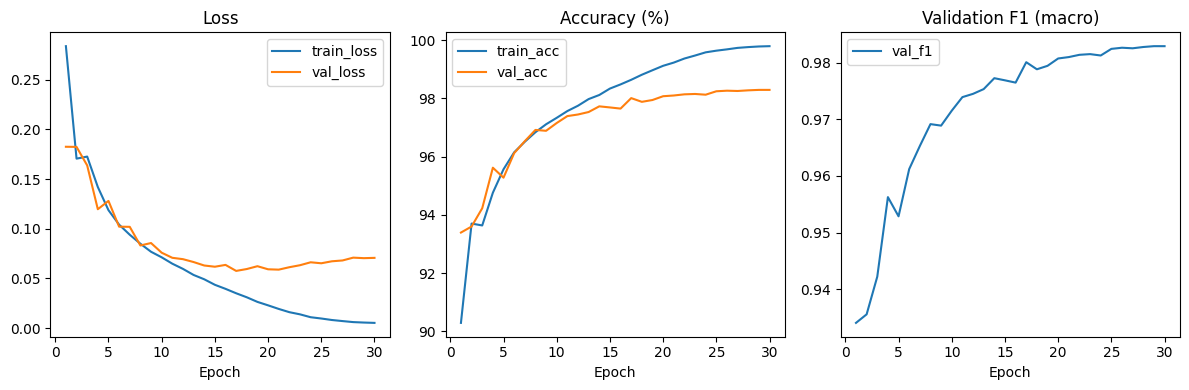

Saved training curves to /kaggle/working/poultry_model/training_curves.png


In [10]:
# Cell 10 - plot training curves
import matplotlib.pyplot as plt
history = history  # from training cell
epochs = len(history["train_loss"])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(range(1,epochs+1), history["train_loss"], label="train_loss")
plt.plot(range(1,epochs+1), history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.title("Loss"); plt.legend()

plt.subplot(1,3,2)
plt.plot(range(1,epochs+1), [v*100 for v in history["train_acc"]], label="train_acc")
plt.plot(range(1,epochs+1), [v*100 for v in history["val_acc"]], label="val_acc")
plt.xlabel("Epoch"); plt.title("Accuracy (%)"); plt.legend()

plt.subplot(1,3,3)
plt.plot(range(1,epochs+1), history["val_f1"], label="val_f1")
plt.xlabel("Epoch"); plt.title("Validation F1 (macro)"); plt.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"training_curves.png", dpi=150)
plt.show()
print("Saved training curves to", OUTPUT_DIR/"training_curves.png")


# Confusion matrix plot (matplotlib only)

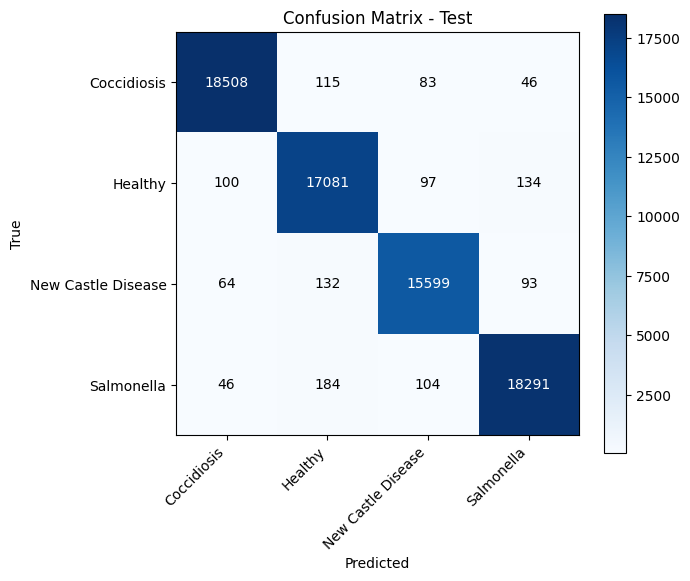

Saved confusion matrix to /kaggle/working/poultry_model/confusion_matrix.png


In [11]:
# Cell 11 - plot confusion matrix
cm = metrics["confusion_matrix"]
classes = UNIFIED_CLASSES

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(classes)), yticks=np.arange(len(classes)),
       xticklabels=classes, yticklabels=classes, ylabel='True', xlabel='Predicted', title='Confusion Matrix - Test')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(int(cm[i, j]), 'd'), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
fig.tight_layout()
plt.savefig(OUTPUT_DIR/"confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved confusion matrix to", OUTPUT_DIR/"confusion_matrix.png")


# Save exportable model & metadata for Django backend

In [12]:
# Cell 12 - save exportable model state dict and metadata
export_path = OUTPUT_DIR / "efficientnet_b0_best.pth"
torch.save({"model_state_dict": plain_model.state_dict(),
            "classes": UNIFIED_CLASSES,
            "input_size": IMG_SIZE,
            "mean":[0.485,0.456,0.406],
            "std":[0.229,0.224,0.225],
            "timm_model":"efficientnet_b0"}, export_path)
with open(OUTPUT_DIR/"metadata.json","w") as f:
    json.dump({"model_file": str(export_path.name), "classes":UNIFIED_CLASSES, "input_size":IMG_SIZE}, f, indent=2)
print("Saved exportable model to", export_path)


Saved exportable model to /kaggle/working/poultry_model/efficientnet_b0_best.pth


# Inference helper (use in Django model_loader.py)

In [13]:
# Cell 13 - inference helper: loads the exported state dict and returns top-k
import torch.nn.functional as F
def load_exported_model(export_file):
    d = torch.load(export_file, map_location="cpu")
    m = create_model(num_classes=len(d["classes"]), pretrained=False)
    m.load_state_dict(d["model_state_dict"])
    m.eval()
    return m, d

def predict_image(model, image_path, topk=3):
    img = Image.open(image_path).convert("RGB")
    t = val_transform(img)
    if isinstance(t, dict):  # if using albumentations
        tensor = t["image"].unsqueeze(0)
    else:
        # torchvision transform returns tensor direct
        tensor = val_transform(img).unsqueeze(0)
    tensor = tensor.to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    idx = probs.argsort()[-topk:][::-1]
    return [{"class": UNIFIED_CLASSES[i], "prob": float(probs[i])} for i in idx]

# Example:
# model_loaded, meta = load_exported_model(OUTPUT_DIR/"efficientnet_b0_best.pth")
# print(predict_image(model_loaded.to(device), str(test_dataset.samples[0][0])))
